# **Homework 4**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

### **Importing Required Libraries**

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import gzip
import struct

## **Step 1: Data Acquisition and Visualization**

In [19]:
def read_idx(filename):
    with gzip.open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

In [20]:
# Load training and test data
train_images = read_idx('train-images-idx3-ubyte.gz')
train_labels = read_idx('train-labels-idx1-ubyte.gz')
test_images = read_idx('t10k-images-idx3-ubyte.gz')
test_labels = read_idx('t10k-labels-idx1-ubyte.gz')

train_images.shape

(60000, 28, 28)

In [21]:
train_labels.shape

(60000,)

In [22]:
test_images.shape

(10000, 28, 28)

In [23]:
test_labels.shape

(10000,)

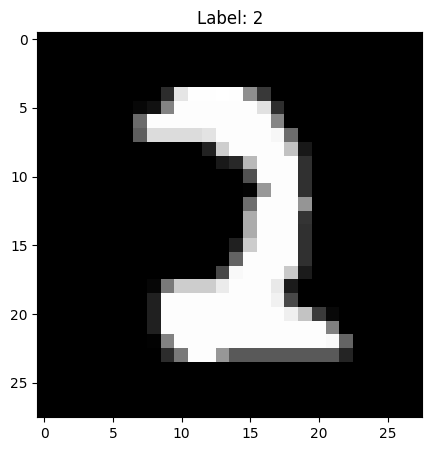

In [24]:
# (b) Visualize a random sample
np.random.seed(695)
random_idx = np.random.randint(0, len(train_images))
img = train_images[random_idx]
label = train_labels[random_idx]
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

### **Observation:**
The dataset consists of grayscale 28x28 images of digits (0-9). Each image is labeled accordingly.


## **Step 2: Data Preprocessing**

In [25]:
# (a) Normalize pixel values to be between 0 and 1
X_train = train_images.astype('float32') / 255.0
X_test = test_images.astype('float32') / 255.0

# (b) Convert labels to one-hot encoding
y_train = np.eye(10)[train_labels]
y_test = np.eye(10)[test_labels]

print(f"Original label: {train_labels[random_idx]}")
print(f"One-hot encoded label: {y_train[random_idx]}")

Original label: 2
One-hot encoded label: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


### **Insight:**
Normalizing the pixel values ensures that the model converges faster. One-hot encoding is crucial for multi-class classification using softmax.


## **Step 3: Network Initialization**

In [26]:
# (a) Define activation functions and their derivatives
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1.0 - a)

def softmax(z):
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [27]:
# (b) Initialize network parameters
# Set seed for reproducibility
np.random.seed(695)
input_size = 28 * 28  # 784
hidden1_size = 128
hidden2_size = 64
output_size = 10  # 10 classes

# Initialize weights and biases
W1 = np.random.uniform(-0.1, 0.1, (input_size, hidden1_size))
b1 = np.zeros((1, hidden1_size))
W2 = np.random.uniform(-0.1, 0.1, (hidden1_size, hidden2_size))
b2 = np.zeros((1, hidden2_size))
W3 = np.random.uniform(-0.1, 0.1, (hidden2_size, output_size))
b3 = np.zeros((1, output_size))

print(f"W1 shape: {W1.shape}")
print(f"b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}")
print(f"b2 shape: {b2.shape}")
print(f"W3 shape: {W3.shape}")
print(f"b3 shape: {b3.shape}")

W1 shape: (784, 128)
b1 shape: (1, 128)
W2 shape: (128, 64)
b2 shape: (1, 64)
W3 shape: (64, 10)
b3 shape: (1, 10)


### **Explanation:**
- We use small random weights to break symmetry and prevent neurons from learning the same function.
- The biases are initialized to zero.

## **Step 4: Feed Forward**

In [28]:
def feed_forward(X, W1, b1, W2, b2, W3, b3):
    # Make sure input is flattened
    if len(X.shape) > 2:
        X = X.reshape(X.shape[0], -1)
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    cache = {
        'X': X, 'Z1': Z1, 'A1': A1,
        'Z2': Z2, 'A2': A2,
        'Z3': Z3, 'A3': A3
    }

    return A3, cache

## **Step 5: Back Propagation**

In [29]:
# (a) Categorical cross entropy loss function
def categorical_crossentropy(y_true, y_pred):
    n_samples = y_true.shape[0]
    y_pred_clipped = np.clip(y_pred, 1e-12, 1 - 1e-12)
    return -np.sum(y_true * np.log(y_pred_clipped)) / n_samples